# **Questioning the Lognormal Assumption in BSM**

## 1. Motivation

대학교에서 전공 수업과 CFA 준비를 병행하던 시기에 **Black–Scholes–Merton(BSM) 모형**은 개인적으로 꽤 인상적인 모델이었다. 금융이론, 확률과정, 그리고 통계적 사고가 하나의 수식 구조 안에서 자연스럽게 연결되는 느낌이 있었기 때문이다. 단순히 옵션 가격을 계산하는 공식이라기보다 **금융시장에 대한 통계적 가정을 기반으로 한 구조적 모델**이라는 점이 흥미롭게 다가왔다.

예전부터 BSM과 관련된 데이터 기반 분석을 한 번쯤 해보고 싶었다. 물론 BSM을 중심으로 다룰 수 있는 주제는 매우 다양하다. 변동성 추정, 옵션 가격의 오차, implied volatility structure 등 여러 흥미로운 논의가 가능하다. 하지만 처음 이 모형을 블로그에서 언급하며 다루는 만큼, 이번 글에서는 비교적 가벼운 질문에서 출발하고자 한다.

이번 분석의 출발점은 다음과 같다.

- **주식 가격은 정말 로그정규분포(Lognormal Distribution)를 따르는가?**  
- **실제 시장 데이터는 이 가정을 얼마나 잘 설명하는가?**  
- **혹시 더 적합한 분포가 존재할 가능성은 없는가?**

BSM 모형의 여러 가정 중에서도 **로그정규분포 가정은 가장 핵심적인 출발점**이다. 따라서 이번 글에서는 실제 주식 데이터를 통해 이 가정을 간단히 확인해 보고, 현실 데이터가 이 이론적 구조와 얼마나 잘 맞는지를 살펴보고자 한다.

거창한 결론을 도출하기보다는, **이론적 가정과 실제 데이터 사이의 간단한 empirical check**라는 가벼운 성격의 분석으로 접근할 것이다.

---

## 2. The Black–Scholes–Merton Framework

Black–Scholes–Merton 모형은 옵션 가격을 결정하기 위한 대표적인 연속시간 금융모형이다. 이 모형의 핵심 가정은 **주식 가격이 기하 브라운 운동(Geometric Brownian Motion)을 따른다**는 것이다.

주가 과정은 다음과 같은 확률미분방정식으로 표현된다.

$$
dS_t = \mu S_t dt + \sigma S_t dW_t
$$

where

- $S_t$ : time $t$에서의 주가  
- $\mu$ : 기대수익률 (drift)  
- $\sigma$ : 변동성 (volatility)  
- $W_t$ : Brownian motion

이 확률미분방정식을 풀면 주가의 분포는 다음과 같은 형태로 표현된다.

$$
S_T = S_0 \exp \left[ \left(\mu - \frac{1}{2}\sigma^2 \right)T + \sigma W_T \right]
$$

따라서 로그수익률은 정규분포를 따르게 된다.

$$
\ln \left(\frac{S_T}{S_0}\right)
\sim
N\left(
\left(\mu - \frac{1}{2}\sigma^2\right)T,
\sigma^2 T
\right)
$$

즉 BSM 모형의 핵심 가정은 다음과 같이 정리할 수 있다.

- **로그수익률(Log return)은 정규분포를 따른다**
- **따라서 주식 가격은 로그정규분포(Lognormal distribution)를 따른다**

이 가정은 수학적으로 매우 편리하며, BSM 옵션 가격 공식이 폐형식(closed-form solution)으로 도출되는 중요한 이유이기도 하다.

그러나 실제 금융시장에서는 다음과 같은 경험적 특징이 자주 관찰된다.

- fat tails  
- skewness  
- excess kurtosis  

따라서 자연스럽게 다음 질문이 제기된다.

**실제 주식 데이터는 BSM이 가정하는 lognormal 구조와 얼마나 일치하는가?**

이 질문을 간단한 데이터 분석을 통해 확인해 보는 것이 이번 글의 출발점이다.

## 3. Data

이번 분석에서는 `yfinance`를 통해 수집한 시장 데이터를 활용한다. `yfinance`는 Yahoo Finance에서 제공되는 주가, 옵션 체인, 거래량, 기업 기본정보 등의 데이터를 비교적 간편하게 불러올 수 있는 Python 라이브러리로, 실증적 금융 데이터 분석을 시작할 때 자주 사용된다.

이론적으로는 `yfinance`를 통해 개별 주식의 가격 데이터뿐 아니라 옵션 만기 구조와 실제 옵션가격도 확인할 수 있으므로, 이후 BSM과 실제 시장가격을 비교하는 방향으로도 분석을 확장할 수 있다. 다만 이번 글의 목적은 옵션 가격의 오차를 분석하는 것이 아니라, **BSM의 핵심 가정인 로그정규분포 가정을 간단히 점검하는 것**이므로 우선은 기초자산의 가격 데이터 자체에 집중하고자 한다.

한편 배당(dividend)의 존재는 BSM 구조에도 중요한 영향을 준다. 기본적인 무배당 BSM 모형에서는 주가 과정이 그대로 사용되지만, 배당을 지급하는 주식의 경우 옵션 가치평가식과 기대수익 구조가 달라질 수 있다. 특히 연속배당수익률 $q$를 고려하면 주가 과정은 다음과 같이 수정된다.

$$
dS_t = (\mu - q)S_t dt + \sigma S_t dW_t
$$

또한 옵션 가격 공식에서도 배당수익률이 할인요인으로 반영된다. 즉, 배당이 존재하는 종목은 단순한 가격분포 확인을 넘어 추가적인 해석 요소를 필요로 한다.

이번 글의 목적은 **분포 적합성 자체를 최대한 단순한 형태로 점검하는 것**이므로, 배당의 효과가 분석 결과에 불필요하게 섞이지 않도록 **배당을 지급하지 않는 주식(non-dividend-paying stock)** 을 사용하고자 한다. 여기서 무배당 주식이란 분석 대상 기간 동안 현금배당 지급 이력이 없거나, 적어도 배당수익률의 영향이 사실상 없다고 볼 수 있는 종목을 의미한다.

따라서 이번 데이터 선택의 기준은 다음과 같다.

- `yfinance`를 통해 안정적으로 가격 데이터를 수집할 수 있을 것
- 분석 기간 동안 배당의 영향이 없거나 매우 미미할 것
- 로그수익률 분포를 점검하기에 충분한 시계열 길이를 확보할 수 있을 것

이 기준에 따라 먼저 무배당 주식의 일별 종가 데이터를 수집하고, 이를 바탕으로 로그수익률을 계산한 뒤 BSM의 로그정규분포 가정을 점검할 것이다.

자료의 분석에는 무배당주로 대표적인 테슬라의 주식을 사용하기로 결정하였다.



In [30]:
import numpy as np
import pandas as pd
import yfinance as yf

ticker = "TSLA"
start_date = "2020-01-01"
end_date = "2025-01-01"

stock = yf.Ticker(ticker)

# 가격 데이터 다운로드
price_df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

# 배당 데이터 확인
dividends = stock.dividends

print("Price data head:")
print(price_df.head())
print("\nDividends:")
print(dividends.tail())

# 종가 기준 로그수익률 계산
price_df["Log Return"] = np.log(price_df["Adj Close"] / price_df["Adj Close"].shift(1))

print("\nLog return head:")
print(price_df[["Adj Close", "Log Return"]].dropna().head())

total_dividends = dividends.loc[start_date:end_date].sum()

print(f"Total dividends during sample period: {total_dividends}")

if total_dividends == 0:
    print(f"{ticker} can be treated as a non-dividend-paying stock in this sample period.")
else:
    print(f"{ticker} paid dividends during this sample period. Consider choosing another stock.")

Price data head:
Price       Adj Close      Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                                        
2020-01-02  28.684000  28.684000  28.713333  28.114000  28.299999  142981500
2020-01-03  29.534000  29.534000  30.266666  29.128000  29.366667  266677500
2020-01-06  30.102667  30.102667  30.104000  29.333332  29.364668  151995000
2020-01-07  31.270666  31.270666  31.441999  30.224001  30.760000  268231500
2020-01-08  32.809334  32.809334  33.232666  31.215334  31.580000  467164500

Dividends:
Series([], Name: Dividends, dtype: float64)

Log return head:
Price       Adj Close Log Return
Ticker           TSLA           
Date                            
2020-01-03  29.534000   0.029203
2020-01-06  30.102667   0.019072
2020-01-07  31.270666   0.038067
2020-01-08  32.809334   0.048033
2020-01-09  32.089333  -0.022189
Total dividends during sample

Tesla 주가 데이터를 이용하여 Black–Scholes–Merton (BSM) 모형의 로그정규 분포 가정이 실제 데이터에서 얼마나 타당한지를 간단히 검토해보았다.

본 분석에서는 2020년부터 2025년까지 약 5년간의 Tesla 주가 데이터를 수집하였다. 이후 전체 표본을 시간 순서에 따라 두 개의 하위 표본으로 나누고, 앞의 약 2.5년 데이터를 이용하여 로그수익률의 경험적 분포가 어떤 확률분포에 가장 잘 부합하는지를 역추적하였다.

로그수익률은 다음과 같이 정의된다.

$$
r_t = \log \left(\frac{S_t}{S_{t-1}}\right)
$$

여기서 $S_t$는 시점 $t$의 주가를 의미한다.

여러 후보 분포를 적합시켜 AIC와 Kolmogorov–Smirnov 통계량을 비교한 결과, Tesla의 로그수익률 분포는 정규분포보다 **Laplace 분포에 더 잘 부합하는 것으로 나타났다**. 또한 Jarque–Bera 검정과 Shapiro–Wilk 검정 역시 정규성 가설을 기각하는 결과를 보였다.

이러한 결과는 금융 데이터에서 흔히 관찰되는 특징과도 일치한다. 실제 금융 자산의 수익률 분포는 정규분포보다 **fat tail(두꺼운 꼬리)** 특성을 보이는 경우가 많으며, 이는 극단적인 가격 변동이 정규분포가 예측하는 것보다 더 자주 발생한다는 것을 의미한다. Laplace 분포는 정규분포보다 중심이 더 뾰족하고 꼬리가 두꺼운 특성을 가지기 때문에 이러한 금융 수익률 데이터를 더 잘 설명하는 경우가 종종 있다.

아래에서는 실제 데이터를 이용하여 분포 적합을 수행하는 코드를 실행하고, 히스토그램 및 QQ plot을 통해 각 분포의 적합도를 시각적으로 비교하였다.

TSLA columns:
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

Total dividends during sample period: 0.0
TSLA can be treated as a non-dividend-paying stock in this sample period.

Sample split:
Full sample size: 1258
First half size: 629
Second half size: 629
First half period: 2020-01-02 to 2022-06-30
Second half period: 2022-07-01 to 2024-12-31

First-half log return summary:
count    628.000000
mean       0.003276
std        0.046712
min       -0.236518
25%       -0.020743
50%        0.002541
75%        0.027023
max        0.181445
dtype: float64

Distribution fit comparison (first-half log returns):
        dist       loglik          aic          bic
0    Laplace  1077.463942 -2150.927885 -2142.042804
1  Student-t  1075.663732 -2145.327465 -2131.999844
2     Normal  1033.446568 -2062.893136 -2054.008056

Best fit by AIC: Laplace

KS test comparison:
        dist   KS stat  KS p-value
0    Laplace  0.024365    0.840891
1  Student-t  0.025

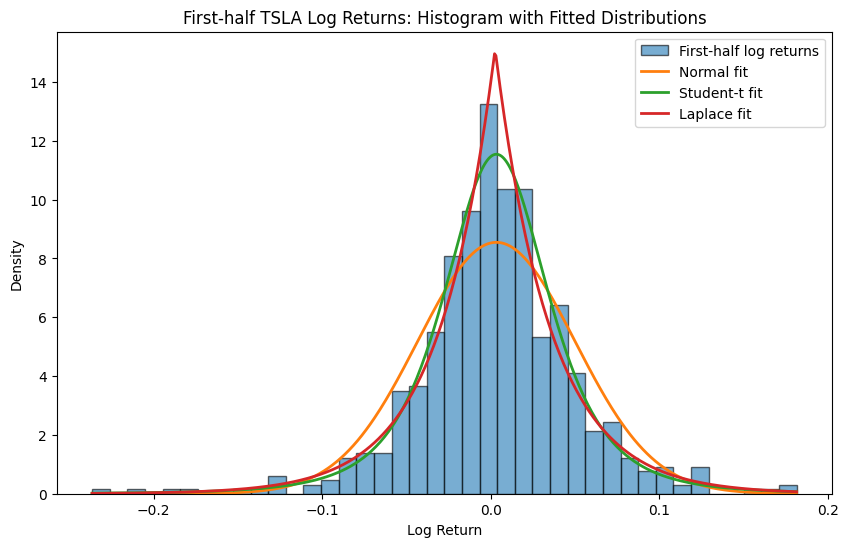

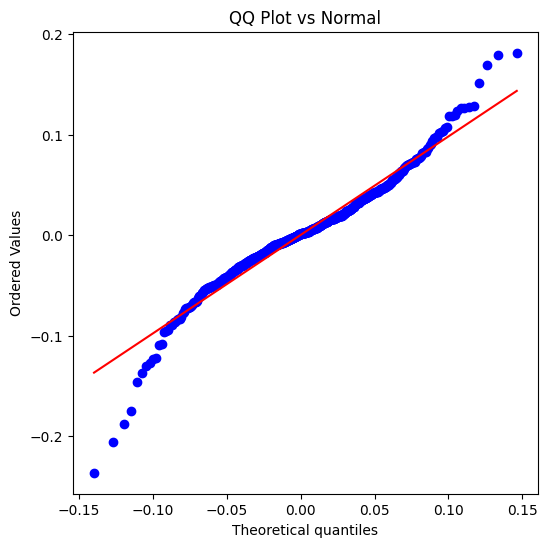

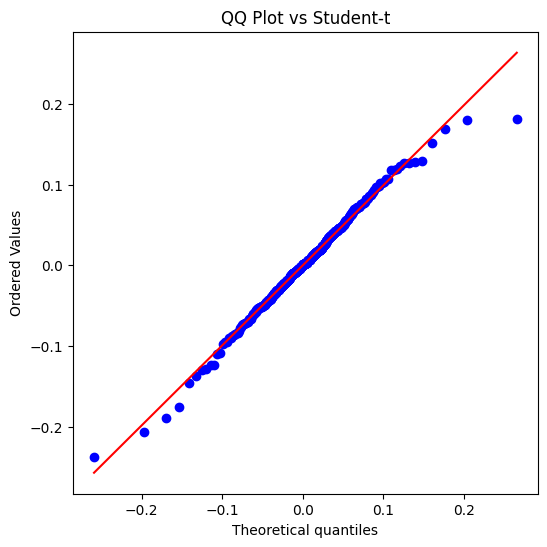

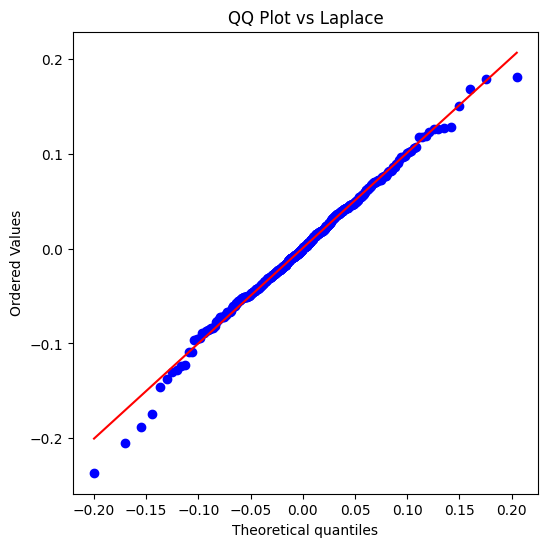


Interpretation:
1. By AIC, the best-fitting distribution is: Laplace
2. By KS statistic, the closest distribution is: Laplace
3. Both Jarque-Bera and Shapiro-Wilk reject normality, suggesting that the normal assumption is weak.
4. Since at least one goodness-of-fit criterion prefers a non-normal distribution, the BSM lognormal assumption may be questionable in this subsample.


In [31]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as st
import matplotlib.pyplot as plt

ticker = "TSLA"
start_date = "2020-01-01"
end_date = "2025-01-01"

# 1. 가격 데이터 다운로드
raw_df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)
# 2. TSLA만 따로 데이터프레임으로 정리
# yfinance 버전에 따라 컬럼 구조가 달라질 수 있어서 분기 처리
if isinstance(raw_df.columns, pd.MultiIndex):
    TSLA = raw_df.xs(ticker, axis=1, level=-1).copy()
else:
    TSLA = raw_df.copy()
# 컬럼 이름 확인용
print("TSLA columns:")
print(TSLA.columns)
# 3. 배당 확인
stock = yf.Ticker(ticker)
dividends = stock.dividends.loc[start_date:end_date]
total_dividends = dividends.sum()
print(f"\nTotal dividends during sample period: {total_dividends}")
if total_dividends == 0:
    print(f"{ticker} can be treated as a non-dividend-paying stock in this sample period.")
else:
    print(f"{ticker} paid dividends during this sample period.")
# 4. 로그수익률 계산
TSLA["Log Return"] = np.log(TSLA["Adj Close"] / TSLA["Adj Close"].shift(1))
# 5. 표본을 절반으로 분할 (시간순)
split_idx = len(TSLA) // 2
TSLA_first = TSLA.iloc[:split_idx].copy()
TSLA_second = TSLA.iloc[split_idx:].copy()
print("\nSample split:")
print("Full sample size:", len(TSLA))
print("First half size:", len(TSLA_first))
print("Second half size:", len(TSLA_second))
print("First half period:", TSLA_first.index.min().date(), "to", TSLA_first.index.max().date())
print("Second half period:", TSLA_second.index.min().date(), "to", TSLA_second.index.max().date())
# 6. 앞 절반의 로그수익률 추출
r = TSLA_first["Log Return"].dropna().values

print("\nFirst-half log return summary:")
print(pd.Series(r).describe())



def fit_normal(x):
    params = st.norm.fit(x)   # (mu, sigma)
    loglik = np.sum(st.norm.logpdf(x, *params))
    k = len(params)
    return {
        "dist": "Normal",
        "params": params,
        "loglik": loglik,
        "aic": 2 * k - 2 * loglik,
        "bic": k * np.log(len(x)) - 2 * loglik
    }

def fit_t(x):
    params = st.t.fit(x)      # (df, loc, scale)
    loglik = np.sum(st.t.logpdf(x, *params))
    k = len(params)
    return {
        "dist": "Student-t",
        "params": params,
        "loglik": loglik,
        "aic": 2 * k - 2 * loglik,
        "bic": k * np.log(len(x)) - 2 * loglik
    }

def fit_laplace(x):
    params = st.laplace.fit(x)   # (loc, scale)
    loglik = np.sum(st.laplace.logpdf(x, *params))
    k = len(params)
    return {
        "dist": "Laplace",
        "params": params,
        "loglik": loglik,
        "aic": 2 * k - 2 * loglik,
        "bic": k * np.log(len(x)) - 2 * loglik
    }

fit_results = [
    fit_normal(r),
    fit_t(r),
    fit_laplace(r)
]

fit_table = pd.DataFrame(fit_results).sort_values("aic").reset_index(drop=True)

print("\nDistribution fit comparison (first-half log returns):")
print(fit_table[["dist", "loglik", "aic", "bic"]])

best_dist_name = fit_table.loc[0, "dist"]
print(f"\nBest fit by AIC: {best_dist_name}")

# -------------------------------------------------------
# KS test
# -------------------------------------------------------
ks_results = []

for res in fit_results:
    if res["dist"] == "Normal":
        ks_stat, ks_p = st.kstest(r, "norm", args=res["params"])
    elif res["dist"] == "Student-t":
        ks_stat, ks_p = st.kstest(r, "t", args=res["params"])
    elif res["dist"] == "Laplace":
        ks_stat, ks_p = st.kstest(r, "laplace", args=res["params"])
    else:
        ks_stat, ks_p = np.nan, np.nan

    ks_results.append({
        "dist": res["dist"],
        "KS stat": ks_stat,
        "KS p-value": ks_p
    })

ks_table = pd.DataFrame(ks_results).sort_values("KS stat").reset_index(drop=True)

print("\nKS test comparison:")
print(ks_table)

# -------------------------------------------------------
# 정규성 자체 확인
# -------------------------------------------------------
jb_stat, jb_p = st.jarque_bera(r)
sw_stat, sw_p = st.shapiro(r)

print("\nNormality tests for first-half log returns:")
print(f"Jarque-Bera stat = {jb_stat:.4f}, p-value = {jb_p:.6f}")
print(f"Shapiro-Wilk stat = {sw_stat:.4f}, p-value = {sw_p:.6f}")

if jb_p < 0.05:
    print("Jarque-Bera rejects normality at the 5% level.")
else:
    print("Jarque-Bera does not reject normality at the 5% level.")

if sw_p < 0.05:
    print("Shapiro-Wilk rejects normality at the 5% level.")
else:
    print("Shapiro-Wilk does not reject normality at the 5% level.")

# -------------------------------------------------------
# 히스토그램 + 적합 분포
# -------------------------------------------------------
x_grid = np.linspace(r.min(), r.max(), 500)

plt.figure(figsize=(10, 6))
plt.hist(r, bins=40, density=True, alpha=0.6, edgecolor="black", label="First-half log returns")

# Normal
norm_params = [res["params"] for res in fit_results if res["dist"] == "Normal"][0]
plt.plot(x_grid, st.norm.pdf(x_grid, *norm_params), linewidth=2, label="Normal fit")

# Student-t
t_params = [res["params"] for res in fit_results if res["dist"] == "Student-t"][0]
plt.plot(x_grid, st.t.pdf(x_grid, *t_params), linewidth=2, label="Student-t fit")

# Laplace
lap_params = [res["params"] for res in fit_results if res["dist"] == "Laplace"][0]
plt.plot(x_grid, st.laplace.pdf(x_grid, *lap_params), linewidth=2, label="Laplace fit")

plt.title("First-half TSLA Log Returns: Histogram with Fitted Distributions")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.show()

# -------------------------------------------------------
# QQ plot: Normal
# -------------------------------------------------------
plt.figure(figsize=(6, 6))
st.probplot(r, dist="norm", sparams=norm_params, plot=plt)
plt.title("QQ Plot vs Normal")
plt.show()

# -------------------------------------------------------
# QQ plot: Student-t
# -------------------------------------------------------
plt.figure(figsize=(6, 6))
st.probplot(r, dist=st.t, sparams=t_params, plot=plt)
plt.title("QQ Plot vs Student-t")
plt.show()

# -------------------------------------------------------
# QQ plot: Laplace
# -------------------------------------------------------

plt.figure(figsize=(6,6))

st.probplot(
    r,
    dist=st.laplace,
    sparams=lap_params,
    plot=plt
)

plt.title("QQ Plot vs Laplace")
plt.show()
# -------------------------------------------------------
# 근거 자동 요약
# -------------------------------------------------------
best_aic = fit_table.loc[0, "dist"]
best_ks = ks_table.loc[0, "dist"]

print("\nInterpretation:")
print(f"1. By AIC, the best-fitting distribution is: {best_aic}")
print(f"2. By KS statistic, the closest distribution is: {best_ks}")

if jb_p < 0.05 and sw_p < 0.05:
    print("3. Both Jarque-Bera and Shapiro-Wilk reject normality, suggesting that the normal assumption is weak.")
else:
    print("3. Normality is not strongly rejected by all tests, so the evidence against normality is limited.")

if best_aic != "Normal" or best_ks != "Normal":
    print("4. Since at least one goodness-of-fit criterion prefers a non-normal distribution, the BSM lognormal assumption may be questionable in this subsample.")
else:
    print("4. Since normal distribution remains competitive, the BSM lognormal assumption is not strongly contradicted in this subsample.")

앞서 첫 번째 하위 표본(약 2.5년 데이터)을 이용하여 Tesla 로그수익률의 경험적 분포를 분석한 결과, 정규분포보다는 Laplace 분포가 더 높은 적합도를 보이는 것으로 나타났다. 이는 금융 자산 수익률에서 자주 관찰되는 fat tail 특성과도 일치하는 결과이다.

이러한 결과가 특정 기간에만 나타나는 현상인지 확인하기 위해, 동일한 분석을 나머지 표본 구간(뒤의 약 2.5년 데이터)에 대해서도 반복 수행하였다. 동일하게 로그수익률을 다음과 같이 정의하였다.

$$
r_t = \log \left(\frac{S_t}{S_{t-1}}\right)
$$

여기서 $S_t$는 시점 $t$의 주가를 의미한다.

두 번째 하위 표본에 대해서도 동일하게 여러 후보 분포를 적합시키고 AIC 및 Kolmogorov–Smirnov 통계량을 비교하였다. 또한 Jarque–Bera 검정과 Shapiro–Wilk 검정을 통해 정규성 가설을 검정하였다. 이러한 절차를 통해 첫 번째 표본에서 관찰된 분포 특성이 시간에 따라 안정적으로 나타나는지 여부를 경험적으로 확인하고자 하였다.

아래에서는 동일한 방법을 이용하여 두 번째 하위 표본의 로그수익률 분포를 추정하고, 히스토그램 및 QQ plot을 통해 분포 적합도를 시각적으로 비교하였다.

count    629.000000
mean       0.000934
std        0.037166
min       -0.131643
25%       -0.019396
50%        0.001463
75%        0.020607
max        0.198187
dtype: float64

Distribution fit comparison (second-half log returns):
        dist       loglik          aic          bic
0  Student-t  1203.119394 -2400.238788 -2386.906395
1    Laplace  1201.154375 -2398.308750 -2389.420487
2     Normal  1178.876894 -2353.753787 -2344.865525

KS test comparison (second half):
        dist   KS stat  KS p-value
0  Student-t  0.019579    0.965538
1    Laplace  0.043892    0.171968
2     Normal  0.053922    0.049706

Normality tests (second-half log returns):
Jarque-Bera stat = 146.2982, p-value = 0.000000
Shapiro-Wilk stat = 0.9749, p-value = 0.000000
Jarque-Bera rejects normality at the 5% level.
Shapiro-Wilk rejects normality at the 5% level.


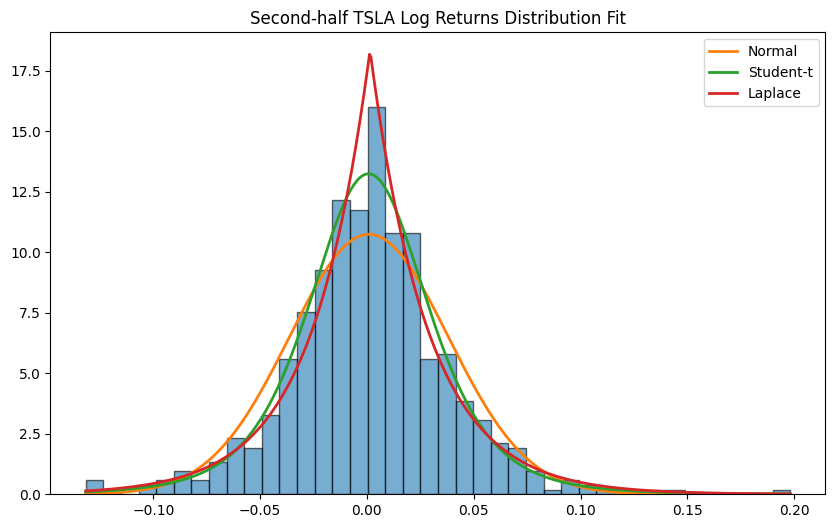

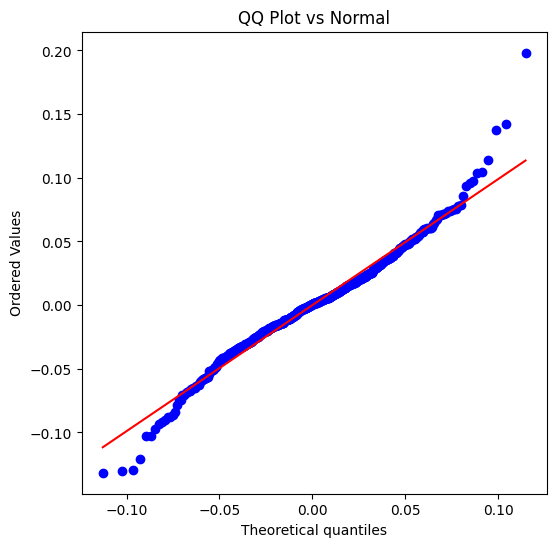

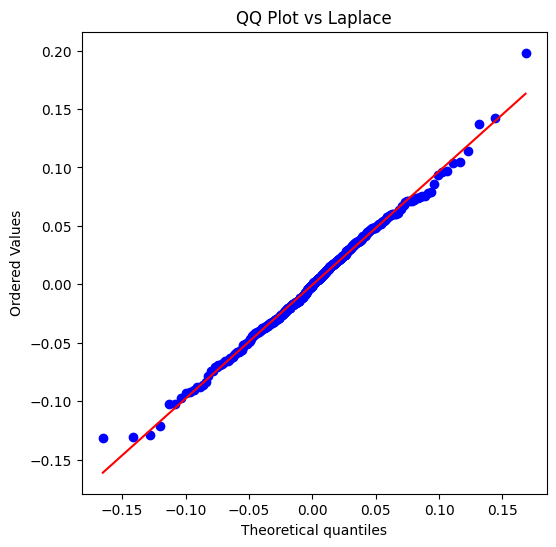

In [32]:
r2 = TSLA_second["Log Return"].dropna().values

print(pd.Series(r2).describe())

fit_results2 = [
    fit_normal(r2),
    fit_t(r2),
    fit_laplace(r2)
]

fit_table2 = pd.DataFrame(fit_results2).sort_values("aic").reset_index(drop=True)

print("\nDistribution fit comparison (second-half log returns):")
print(fit_table2[["dist", "loglik", "aic", "bic"]])

ks_results2 = []

for res in fit_results2:
    if res["dist"] == "Normal":
        ks_stat, ks_p = st.kstest(r2, "norm", args=res["params"])
    elif res["dist"] == "Student-t":
        ks_stat, ks_p = st.kstest(r2, "t", args=res["params"])
    elif res["dist"] == "Laplace":
        ks_stat, ks_p = st.kstest(r2, "laplace", args=res["params"])

    ks_results2.append({
        "dist": res["dist"],
        "KS stat": ks_stat,
        "KS p-value": ks_p
    })

ks_table2 = pd.DataFrame(ks_results2).sort_values("KS stat").reset_index(drop=True)

print("\nKS test comparison (second half):")
print(ks_table2)

jb_stat2, jb_p2 = st.jarque_bera(r2)
sw_stat2, sw_p2 = st.shapiro(r2)

print("\nNormality tests (second-half log returns):")
print(f"Jarque-Bera stat = {jb_stat2:.4f}, p-value = {jb_p2:.6f}")
print(f"Shapiro-Wilk stat = {sw_stat2:.4f}, p-value = {sw_p2:.6f}")

if jb_p2 < 0.05:
    print("Jarque-Bera rejects normality at the 5% level.")
else:
    print("Jarque-Bera does not reject normality at the 5% level.")

if sw_p2 < 0.05:
    print("Shapiro-Wilk rejects normality at the 5% level.")
else:
    print("Shapiro-Wilk does not reject normality at the 5% level.")

x_grid = np.linspace(r2.min(), r2.max(), 500)

plt.figure(figsize=(10,6))
plt.hist(r2, bins=40, density=True, alpha=0.6, edgecolor="black")

norm_params2 = [res["params"] for res in fit_results2 if res["dist"] == "Normal"][0]
plt.plot(x_grid, st.norm.pdf(x_grid, *norm_params2), linewidth=2, label="Normal")

t_params2 = [res["params"] for res in fit_results2 if res["dist"] == "Student-t"][0]
plt.plot(x_grid, st.t.pdf(x_grid, *t_params2), linewidth=2, label="Student-t")

lap_params2 = [res["params"] for res in fit_results2 if res["dist"] == "Laplace"][0]
plt.plot(x_grid, st.laplace.pdf(x_grid, *lap_params2), linewidth=2, label="Laplace")

plt.legend()
plt.title("Second-half TSLA Log Returns Distribution Fit")
plt.show()

plt.figure(figsize=(6,6))
st.probplot(r2, dist="norm", sparams=norm_params2, plot=plt)
plt.title("QQ Plot vs Normal")
plt.show()

plt.figure(figsize=(6,6))
st.probplot(r2, dist=st.laplace, sparams=lap_params2, plot=plt)
plt.title("QQ Plot vs Laplace")
plt.show()



두 번째 하위 표본에 대한 분석 결과, Tesla 로그수익률 분포는 Student-t 분포가 가장 높은 적합도를 보이는 것으로 나타났다. 이는 AIC 기준과 Kolmogorov–Smirnov 통계량 기준 모두에서 확인된 결과이다. 또한 Jarque–Bera 검정과 Shapiro–Wilk 검정 역시 정규성 가설을 기각하는 결과를 보였다.

앞서 분석한 첫 번째 하위 표본에서는 Laplace 분포가 가장 높은 적합도를 보였다는 점을 고려하면, 두 기간 모두에서 정규분포보다 꼬리가 두꺼운 분포가 실제 데이터에 더 잘 부합하는 경향이 관찰된다고 해석할 수 있다. 즉 서로 다른 하위 표본에서도 정규분포보다 heavy-tailed 분포가 상대적으로 더 높은 적합도를 보이는 결과가 나타난 것이다.

물론 실제 금융 데이터를 여러 확률분포에 적합시키면 정규분포보다 더 높은 적합도를 보이는 분포가 발견되는 것은 자연스러운 결과일 수도 있다. 그럼에도 불구하고 이러한 과정을 통해 실제 데이터의 분포 특성을 직접 확인하고, 모형의 기본 가정과 현실 데이터 사이의 차이를 육안으로 확인해보는 작업은 의미가 있다고 생각된다.

특히 금융 자산 수익률은 정규분포보다 더 두꺼운 꼬리를 보이는 경우가 많으며, 이러한 특성은 옵션 가격 모형과 같은 금융 모형의 가정과도 밀접하게 관련된다. 따라서 다음 글에서는 극단적 수익률의 발생 빈도(extreme return frequency)와 같은 tail behavior를 보다 정량적으로 분석하여 금융 데이터의 fat-tail 특성을 보다 심화된 방식으로 살펴보고자 한다.